# Hot Coffee

When you wrap your fingers around a ceramic mug filled with hot coffee, the mug will warm your hands, but the coffee will cool down quickly. In contrast, an insulated metal mug with an air layer is designed to prevent heat transfer, so it won't feel warm to the touch even if it contains scalding liquid. But will the coffee in this mug stay warm for a significantly longer period of time?

Let's also consider lids. How crucial is it to use a lid on an insulated cup to maintain the drink's temperature?

In the file `hot-coffee.csv`, we have data recording the temperature (in Fahrenheit) of initially hot coffee every 5 minutes in three types of cups:

- Insulated with a lid
- Insulated without a lid
- Ceramic without a lid

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'hot-coffee.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('hot-coffee.csv')
df

,time,insulated with lid,insulated,ceramic
0,5,146.6,135.5,128.8
1,10,141.0,118.9,113.9
2,15,136.7,107.9,102.5
3,20,132.5,100.5,95.9
4,25,129.0,94.6,90.5
5,30,125.6,90.8,86.3
6,35,123.4,87.6,83.6
7,40,121.6,85.4,81.6
8,45,118.5,82.9,79.8
9,50,117.6,81.3,78.2


### Project Ideas:

- Create a line plot showing the temperature of the coffee in all three scenarios versus time. 

- Follow the Pro Tips for creating line plots.

- For comparison, consider adding a line representing the ambient air temperature, which was 67 degrees Fahrenheit.

Below is a helper function to label lines for your convenience.

In [3]:
def add_end_labels(df, x, column_names, alpha=1, fontweight='normal'):
    for column_name in column_names:
        y = df[column_name].iloc[-1]
        label = f'  {column_name}'
        plt.text(x, y, label, va="center", alpha=alpha, fontweight=fontweight)

In [4]:
# YOUR CODE HERE (add additional cells as needed)

In [14]:
# ── Helper: label each line at its endpoint ───────────────────────────────────
def add_end_labels(df, x, column_names, alpha=1, fontweight='normal'):
    for column_name in column_names:
        y = df[column_name].iloc[-1]
        label = f'  {column_name}'
        plt.text(x, y, label, va="center", alpha=alpha, fontweight=fontweight)

C:\Users\harsh\AppData\Local\Temp\ipykernel_5080\399299512.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


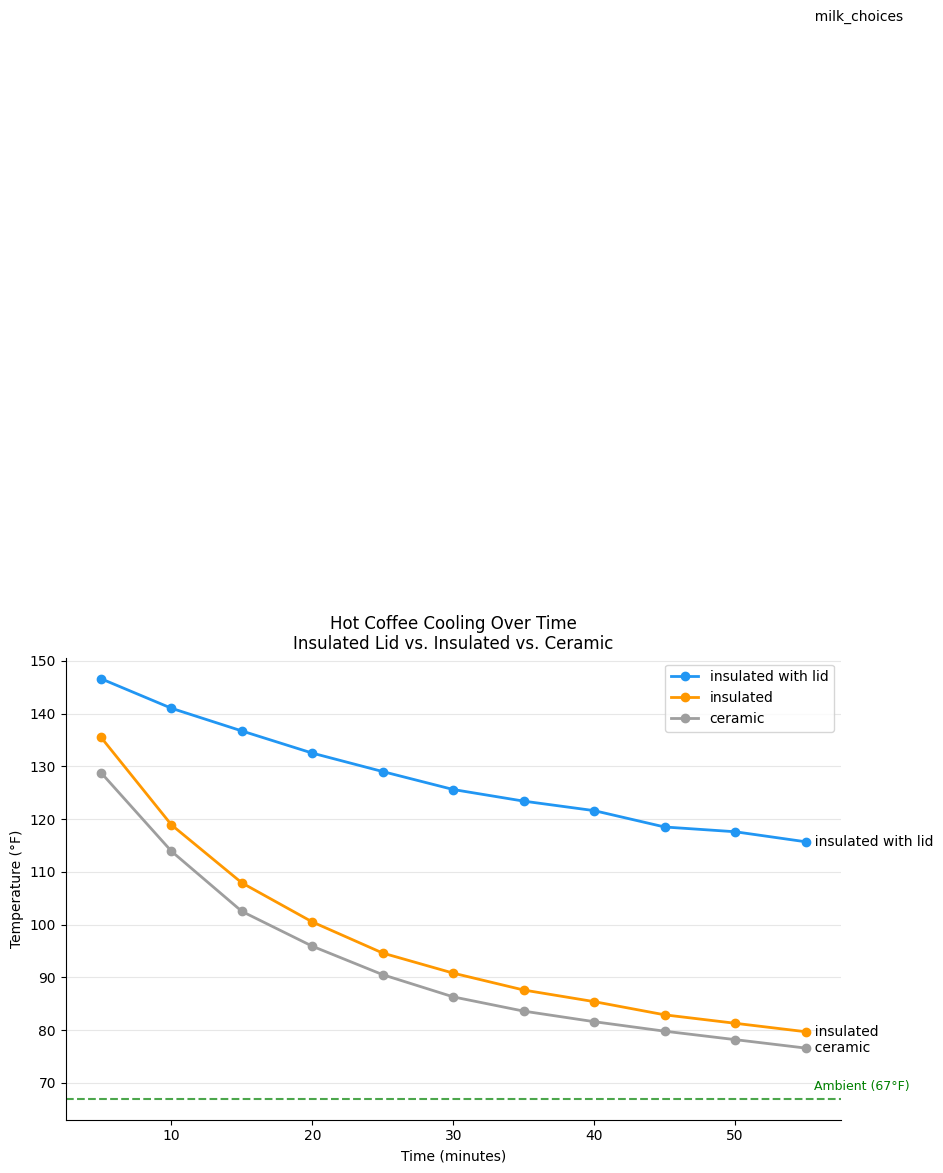

In [19]:
# ── Line plot: Temperature vs Time for all 3 cup types ────────────────────────
AMBIENT_TEMP = 67  # °F

# Identify the time column (assumed to be the first column)
time_col = df.columns[0]
cup_cols = [c for c in df.columns if c != time_col]

plt.figure(figsize=(10, 6))

# Plot each cup type
colors = ['#2196F3', '#FF9800', '#9E9E9E']
for col, color in zip(cup_cols, colors):
    plt.plot(df[time_col], df[col], marker='o', label=col, color=color, linewidth=2)

# Ambient temperature reference line
plt.axhline(y=AMBIENT_TEMP, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(df[time_col].iloc[-1], AMBIENT_TEMP + 1, '  Ambient (67°F)',
         va='bottom', color='green', fontsize=9)

# End labels on each cup line
add_end_labels(df, x=df[time_col].iloc[-1], column_names=cup_cols)

# Formatting (Pro Tips)
plt.xlabel('Time (minutes)')
plt.ylabel('Temperature (°F)')
plt.title('Hot Coffee Cooling Over Time\nInsulated Lid vs. Insulated vs. Ceramic')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

# Remove top and right spines (clean look)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
# ── Summary: Temperature drop per cup type ────────────────────────────────────
print("Temperature Summary")
print("=" * 40)
for col in cup_cols:
    start = df[col].iloc[0]
    end   = df[col].iloc[-1]
    drop  = start - end
    print(f"{col:30s}  Start: {start}°F  |  End: {end}°F  |  Drop: {drop}°F")

Temperature Summary
insulated with lid              Start: 146.6°F  |  End: 115.7°F  |  Drop: 30.89999999999999°F
insulated                       Start: 135.5°F  |  End: 79.7°F  |  Drop: 55.8°F
ceramic                         Start: 128.8°F  |  End: 76.6°F  |  Drop: 52.20000000000002°F
milk_choices                    Start: 410.90000000000003°F  |  End: 272.0°F  |  Drop: 138.90000000000003°F
